In [3]:
import pandas as pd

df = pd.read_csv('survey_nepali_students_jobtype.csv')
df.head()

,Student_ID,Survey_Date,School_Name,Gender,City_Type,Family_Income,Plus2_Stream,Plus2_GPA,Entrance_Score_IOE,Entrance_Score_CEE,...,Interest_Business_Money,Interest_Social_People,Interest_Bio_Health,Interest_Nature_Agri,Interest_Construction,Interest_Law_Politics,Interest_Hospitality_Food,Interest_Gaming_Entertainment,Interest_History_Culture,Suggested_Job_Role
0,STU_1721175,2023-08-05,BernHardt,Male,Rural,High,Science_Physical,3.29,84,0,...,1,4,1,2,1,1,1,1,3,Mgmt_BBA_Marketing
1,STU_5774428,2023-12-24,Kathmandu Model,Male,Rural,Medium,Management,3.14,0,0,...,9,4,1,2,2,1,2,1,2,Mgmt_Supply_Chain
2,STU_9300868,2023-10-02,Gandaki Boarding,Female,Urban,Medium,Management,3.24,0,0,...,4,2,2,2,4,2,3,4,3,IT_QA_Engineer
3,STU_5702202,2023-07-14,St. Xaviers,Female,Rural,Low,Science_Bio,2.86,0,103,...,3,1,9,3,3,2,3,1,2,Med_B_Pharmacy
4,STU_2296617,2023-08-25,Kathmandu Model,Male,Rural,Low,Management,3.15,0,0,...,3,1,3,2,3,1,1,2,3,Mgmt_BBA_Marketing


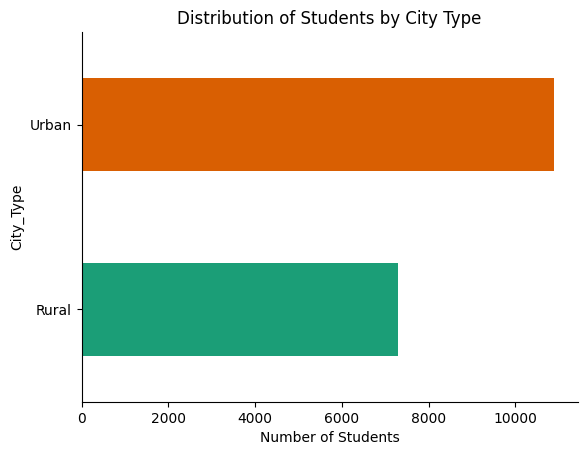

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('City_Type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.xlabel('Number of Students')
plt.title('Distribution of Students by City Type')
plt.gca().spines[['top', 'right',]].set_visible(False)

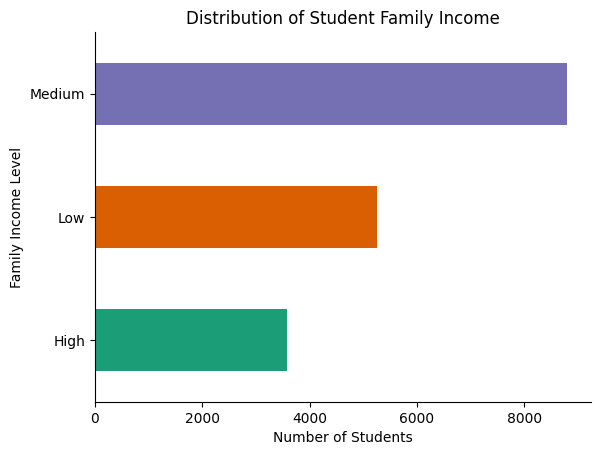

In [5]:
df.groupby('Family_Income').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.xlabel('Number of Students')
plt.ylabel('Family Income Level')
plt.title('Distribution of Student Family Income')
plt.gca().spines[['top', 'right',]].set_visible(False)

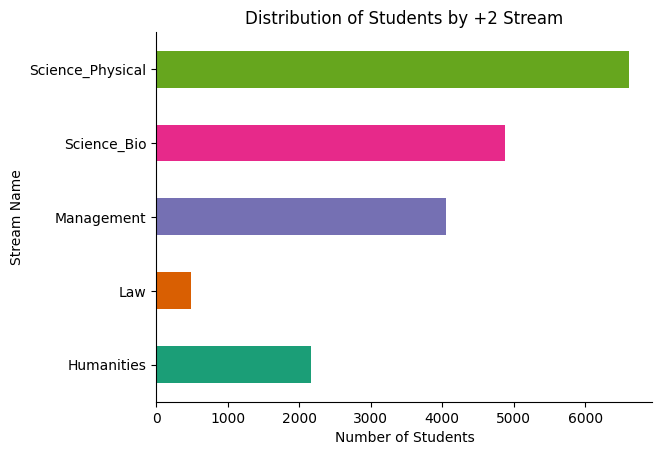

In [6]:
df.groupby('Plus2_Stream').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))

plt.xlabel('Number of Students')
plt.ylabel('Stream Name')
plt.title('Distribution of Students by +2 Stream')

plt.gca().spines[['top', 'right']].set_visible(False)

plt.show()

In [7]:
# gets the length of gpa greater than 4

impossible_gpa_df = df[df['Plus2_GPA'] > 4]

high_gpa_count = len(impossible_gpa_df)
print(f"Total rows with impossible GPA are: {high_gpa_count}")

display(impossible_gpa_df[['Plus2_GPA', 'Suggested_Job_Role']].head())

Total rows with impossible GPA are: 90


,Plus2_GPA,Suggested_Job_Role
128,29.5,IT_QA_Engineer
687,31.6,Mgmt_BBA_Finance
861,35.3,Med_Health_Assistant_HA
1005,37.1,IT_UI_UX_Designer
1022,30.3,Med_BDS_Dentist


In [8]:
# Keep only the rows where GPA is less than or equal to 4
df = df[df['Plus2_GPA'] <= 4]

# Verification
print(f"Remaining rows in dataset: {len(df)}")

Remaining rows in dataset: 18090


In [9]:
df.isnull().sum()

,0
Student_ID,0
Survey_Date,0
School_Name,541
Gender,547
City_Type,0
Family_Income,537
Plus2_Stream,0
Plus2_GPA,0
Entrance_Score_IOE,0
Entrance_Score_CEE,0


In [10]:
df.dropna(inplace=True)
print(f"DataFrame shape after dropping rows with null values: {df.shape}")

DataFrame shape after dropping rows with null values: (15532, 35)


In [11]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 380


In [12]:
# dropped duplicate rows
df.drop_duplicates(inplace=True)
print(f"DataFrame shape after dropping duplicates: {df.shape}")

DataFrame shape after dropping duplicates: (15152, 35)


In [13]:
unnecesary_column = ['School_Name','Survey_Date','Student_ID']
df.drop(columns=unnecesary_column, inplace=True)
df.head()

,Gender,City_Type,Family_Income,Plus2_Stream,Plus2_GPA,Entrance_Score_IOE,Entrance_Score_CEE,Entrance_Score_CMAT,Grade_English,Grade_Nepali,...,Interest_Business_Money,Interest_Social_People,Interest_Bio_Health,Interest_Nature_Agri,Interest_Construction,Interest_Law_Politics,Interest_Hospitality_Food,Interest_Gaming_Entertainment,Interest_History_Culture,Suggested_Job_Role
0,Male,Rural,High,Science_Physical,3.29,84,0,0,A+,A,...,1,4,1,2,1,1,1,1,3,Mgmt_BBA_Marketing
1,Male,Rural,Medium,Management,3.14,0,0,90,A+,A,...,9,4,1,2,2,1,2,1,2,Mgmt_Supply_Chain
2,Female,Urban,Medium,Management,3.24,0,0,86,A,A,...,4,2,2,2,4,2,3,4,3,IT_QA_Engineer
3,Female,Rural,Low,Science_Bio,2.86,0,103,0,B+,A,...,3,1,9,3,3,2,3,1,2,Med_B_Pharmacy
4,Male,Rural,Low,Management,3.15,0,0,86,A+,A,...,3,1,3,2,3,1,1,2,3,Mgmt_BBA_Marketing


In [14]:
from sklearn.preprocessing import LabelEncoder

city_encoder = LabelEncoder()
stream_encoder = LabelEncoder()
target_encoder = LabelEncoder()

# 1. Manually map columns where the order/rank matters
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Family_Income'] = df['Family_Income'].map({'Low': 1, 'Medium': 2, 'High': 3})

df['City_Type'] = city_encoder.fit_transform(df['City_Type'])
df['Plus2_Stream'] = stream_encoder.fit_transform(df['Plus2_Stream'])

display(df.head(15))

,Gender,City_Type,Family_Income,Plus2_Stream,Plus2_GPA,Entrance_Score_IOE,Entrance_Score_CEE,Entrance_Score_CMAT,Grade_English,Grade_Nepali,...,Interest_Business_Money,Interest_Social_People,Interest_Bio_Health,Interest_Nature_Agri,Interest_Construction,Interest_Law_Politics,Interest_Hospitality_Food,Interest_Gaming_Entertainment,Interest_History_Culture,Suggested_Job_Role
0,1,0,3,4,3.29,84,0,0,A+,A,...,1,4,1,2,1,1,1,1,3,Mgmt_BBA_Marketing
1,1,0,2,2,3.14,0,0,90,A+,A,...,9,4,1,2,2,1,2,1,2,Mgmt_Supply_Chain
2,0,1,2,2,3.24,0,0,86,A,A,...,4,2,2,2,4,2,3,4,3,IT_QA_Engineer
3,0,0,1,3,2.86,0,103,0,B+,A,...,3,1,9,3,3,2,3,1,2,Med_B_Pharmacy
4,1,0,1,2,3.15,0,0,86,A+,A,...,3,1,3,2,3,1,1,2,3,Mgmt_BBA_Marketing
5,0,1,2,3,3.95,0,99,0,A+,A+,...,2,3,8,2,4,2,2,1,2,Med_Health_Assistant_HA
6,1,1,3,4,3.01,90,0,0,A,A,...,3,3,2,4,10,1,2,1,1,Eng_Civil_Engineer
7,0,1,2,4,2.89,131,0,0,A+,A,...,4,1,3,3,2,2,1,4,2,IT_AI_ML_Engineer
8,1,1,1,0,3.76,0,0,0,A+,A+,...,3,4,2,1,1,8,3,2,4,Hum_Journalist
10,1,1,1,3,3.37,0,104,0,A+,A,...,1,4,10,2,4,4,2,3,4,Med_BSc_Nursing


In [15]:
from sklearn.preprocessing import StandardScaler

# Identify the columns to be scaled
score_columns = ['Entrance_Score_IOE', 'Entrance_Score_CEE', 'Entrance_Score_CMAT']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected columns
df[score_columns] = scaler.fit_transform(df[score_columns])

print("DataFrame head with scaled entrance scores:")
display(df[score_columns].head())

DataFrame head with scaled entrance scores:


,Entrance_Score_IOE,Entrance_Score_CEE,Entrance_Score_CMAT
0,1.019117,-0.594983,-0.647474
1,-0.742394,-0.594983,1.713980
2,-0.742394,-0.594983,1.609026
3,-0.742394,1.748022,-0.647474
4,-0.742394,-0.594983,1.609026


In [16]:
# 1. Standard NEB Grade to GPA translation
grade_to_gpa = {
    "A+": 4.0, "A": 3.6, "B+": 3.2, "B": 2.8,
    "C+": 2.4, "C": 2.0, "D": 1.6, "NG": 0.0
}

# 2. Select all columns starting with 'Grade_'
grade_cols = df.filter(like='Grade_').columns

# 3. Swap text grades for numbers and fill empty spots with 0
df[grade_cols] = df[grade_cols].replace(grade_to_gpa).fillna(0.0)

# Show results
print("Grades converted to GPA points:")
display(df[grade_cols].head())

Grades converted to GPA points:


/tmp/ipykernel_2818/1729687570.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[grade_cols] = df[grade_cols].replace(grade_to_gpa).fillna(0.0)


,Grade_English,Grade_Nepali,Grade_Social,Grade_Math,Grade_Physics,Grade_Chemistry,Grade_Biology,Grade_Computer,Grade_Accounts,Grade_Economics,Grade_Law
0,4.0,3.6,3.6,4.0,3.6,3.6,0.0,4.0,0.0,0.0,0.0
1,4.0,3.6,3.6,3.6,0.0,0.0,0.0,3.6,3.6,3.6,0.0
2,3.6,3.6,3.2,3.6,0.0,0.0,0.0,3.6,3.2,3.6,0.0
3,3.2,3.6,3.6,3.2,3.6,3.6,3.6,0.0,0.0,0.0,0.0
4,4.0,3.6,3.6,3.2,0.0,0.0,0.0,3.2,3.6,4.0,0.0


In [17]:
# Engineering Delta
df['Delta_Tech_Construction'] = df['Interest_Technology'] - df.get('Interest_Construction', 0)
# Medical Delta
df['Delta_Bio_Tech'] = df['Interest_Bio_Health'] - df['Interest_Technology']
# Management Delta
df['Delta_Money_Creativity'] = df['Interest_Business_Money'] - df['Interest_Art_Design']

# Stream Capability Scores
df['Score_Tech'] = df['Grade_Computer'] + df['Grade_Math'] + df['Grade_Physics']
df['Score_Bio'] = df['Grade_Biology'] + df['Grade_Chemistry']
df['Score_Biz'] = df['Grade_Accounts'] + df['Grade_Economics']

In [18]:
df.head()

,Gender,City_Type,Family_Income,Plus2_Stream,Plus2_GPA,Entrance_Score_IOE,Entrance_Score_CEE,Entrance_Score_CMAT,Grade_English,Grade_Nepali,...,Interest_Hospitality_Food,Interest_Gaming_Entertainment,Interest_History_Culture,Suggested_Job_Role,Delta_Tech_Construction,Delta_Bio_Tech,Delta_Money_Creativity,Score_Tech,Score_Bio,Score_Biz
0,1,0,3,4,3.29,1.019117,-0.594983,-0.647474,4.0,3.6,...,1,1,3,Mgmt_BBA_Marketing,7.0,-7.0,0.0,11.6,3.6,0.0
1,1,0,2,2,3.14,-0.742394,-0.594983,1.713980,4.0,3.6,...,2,1,2,Mgmt_Supply_Chain,1.0,-2.0,7.0,7.2,0.0,7.2
2,0,1,2,2,3.24,-0.742394,-0.594983,1.609026,3.6,3.6,...,3,4,3,IT_QA_Engineer,4.0,-6.0,1.0,7.2,0.0,6.8
3,0,0,1,3,2.86,-0.742394,1.748022,-0.647474,3.2,3.6,...,3,1,2,Med_B_Pharmacy,1.0,5.0,0.0,6.8,7.2,0.0
4,1,0,1,2,3.15,-0.742394,-0.594983,1.609026,4.0,3.6,...,1,2,3,Mgmt_BBA_Marketing,0.0,0.0,2.0,6.4,0.0,7.6


In [19]:
X = df.drop('Suggested_Job_Role', axis=1)
Y = df['Suggested_Job_Role']

print("Head of X (Features):")
display(X.head())

print("\nHead of Y (Target):")
display(Y.head())


Head of X (Features):


,Gender,City_Type,Family_Income,Plus2_Stream,Plus2_GPA,Entrance_Score_IOE,Entrance_Score_CEE,Entrance_Score_CMAT,Grade_English,Grade_Nepali,...,Interest_Law_Politics,Interest_Hospitality_Food,Interest_Gaming_Entertainment,Interest_History_Culture,Delta_Tech_Construction,Delta_Bio_Tech,Delta_Money_Creativity,Score_Tech,Score_Bio,Score_Biz
0,1,0,3,4,3.29,1.019117,-0.594983,-0.647474,4.0,3.6,...,1,1,1,3,7.0,-7.0,0.0,11.6,3.6,0.0
1,1,0,2,2,3.14,-0.742394,-0.594983,1.713980,4.0,3.6,...,1,2,1,2,1.0,-2.0,7.0,7.2,0.0,7.2
2,0,1,2,2,3.24,-0.742394,-0.594983,1.609026,3.6,3.6,...,2,3,4,3,4.0,-6.0,1.0,7.2,0.0,6.8
3,0,0,1,3,2.86,-0.742394,1.748022,-0.647474,3.2,3.6,...,2,3,1,2,1.0,5.0,0.0,6.8,7.2,0.0
4,1,0,1,2,3.15,-0.742394,-0.594983,1.609026,4.0,3.6,...,1,1,2,3,0.0,0.0,2.0,6.4,0.0,7.6



Head of Y (Target):


,Suggested_Job_Role
0,Mgmt_BBA_Marketing
1,Mgmt_Supply_Chain
2,IT_QA_Engineer
3,Med_B_Pharmacy
4,Mgmt_BBA_Marketing


Distribution of Suggested Job Roles:


,count
Suggested_Job_Role,
Eng_Civil_Engineer,449
Agri_Forestry,436
Hum_Economist,433
Agri_Scientist,425
IT_Software_Engineer,422
Med_Veterinary,421
Eng_Architecture,418
Eng_Electronics_Comm,416
Eng_Mechanical,416


/tmp/ipykernel_2818/4141309360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=Y, order = Y.value_counts().index, palette='viridis')


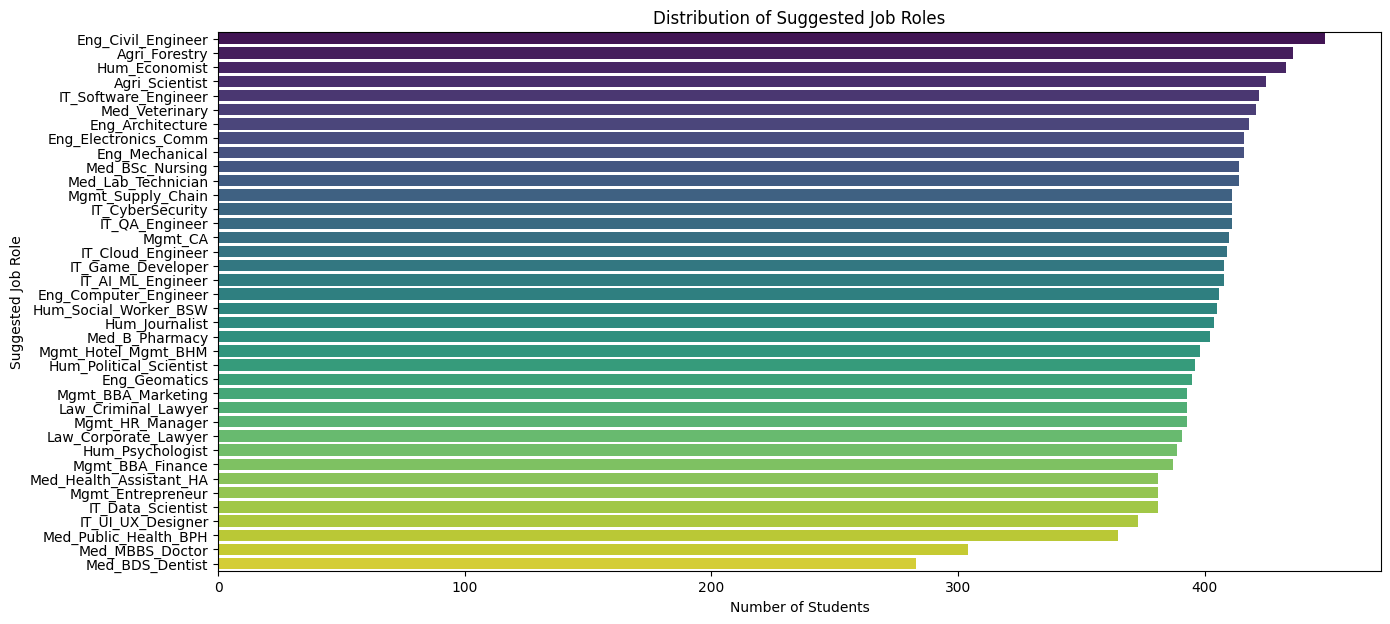

In [20]:
print('Distribution of Suggested Job Roles:')
display(Y.value_counts())

plt.figure(figsize=(15, 7))
sns.countplot(y=Y, order = Y.value_counts().index, palette='viridis')
plt.title('Distribution of Suggested Job Roles')
plt.xlabel('Number of Students')
plt.ylabel('Suggested Job Role')
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (12121, 37)
X_test shape: (3031, 37)
Y_train shape: (12121,)
Y_test shape: (3031,)


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score


Y_train_encoded = target_encoder.fit_transform(Y_train)
Y_test_encoded = target_encoder.transform(Y_test)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced', # Handles the imbalance
    min_samples_leaf=2,      # Smooths out the noise
    random_state=42
)


rf.fit(X_train, Y_train_encoded)


rf_preds = rf.predict(X_test)

print('\n Random Forest Result')
print(f"  Accuracy  : {accuracy_score(Y_test_encoded, rf_preds):.4f}")
print(f"  Precision : {precision_score(Y_test_encoded, rf_preds, average='weighted'):.4f}")
print(f"  Recall    : {recall_score(Y_test_encoded, rf_preds, average='weighted'):.4f}")
print(f"  F1 Score  : {f1_score(Y_test_encoded, rf_preds, average='weighted'):.4f}")



 Random Forest Result
  Accuracy  : 0.7321
  Precision : 0.7395
  Recall    : 0.7321
  F1 Score  : 0.7317


In [23]:
# Cross-validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = cross_val_score(rf, X, Y, cv=skf, scoring='accuracy')

print("\nCross-Validation Accuracy (5-Fold)")
print(f"Random Forest       : {rf_cv.mean():.4f} Standard Deviation {rf_cv.std():.4f}")


Cross-Validation Accuracy (5-Fold)
Random Forest       : 0.7263 Standard Deviation 0.0032


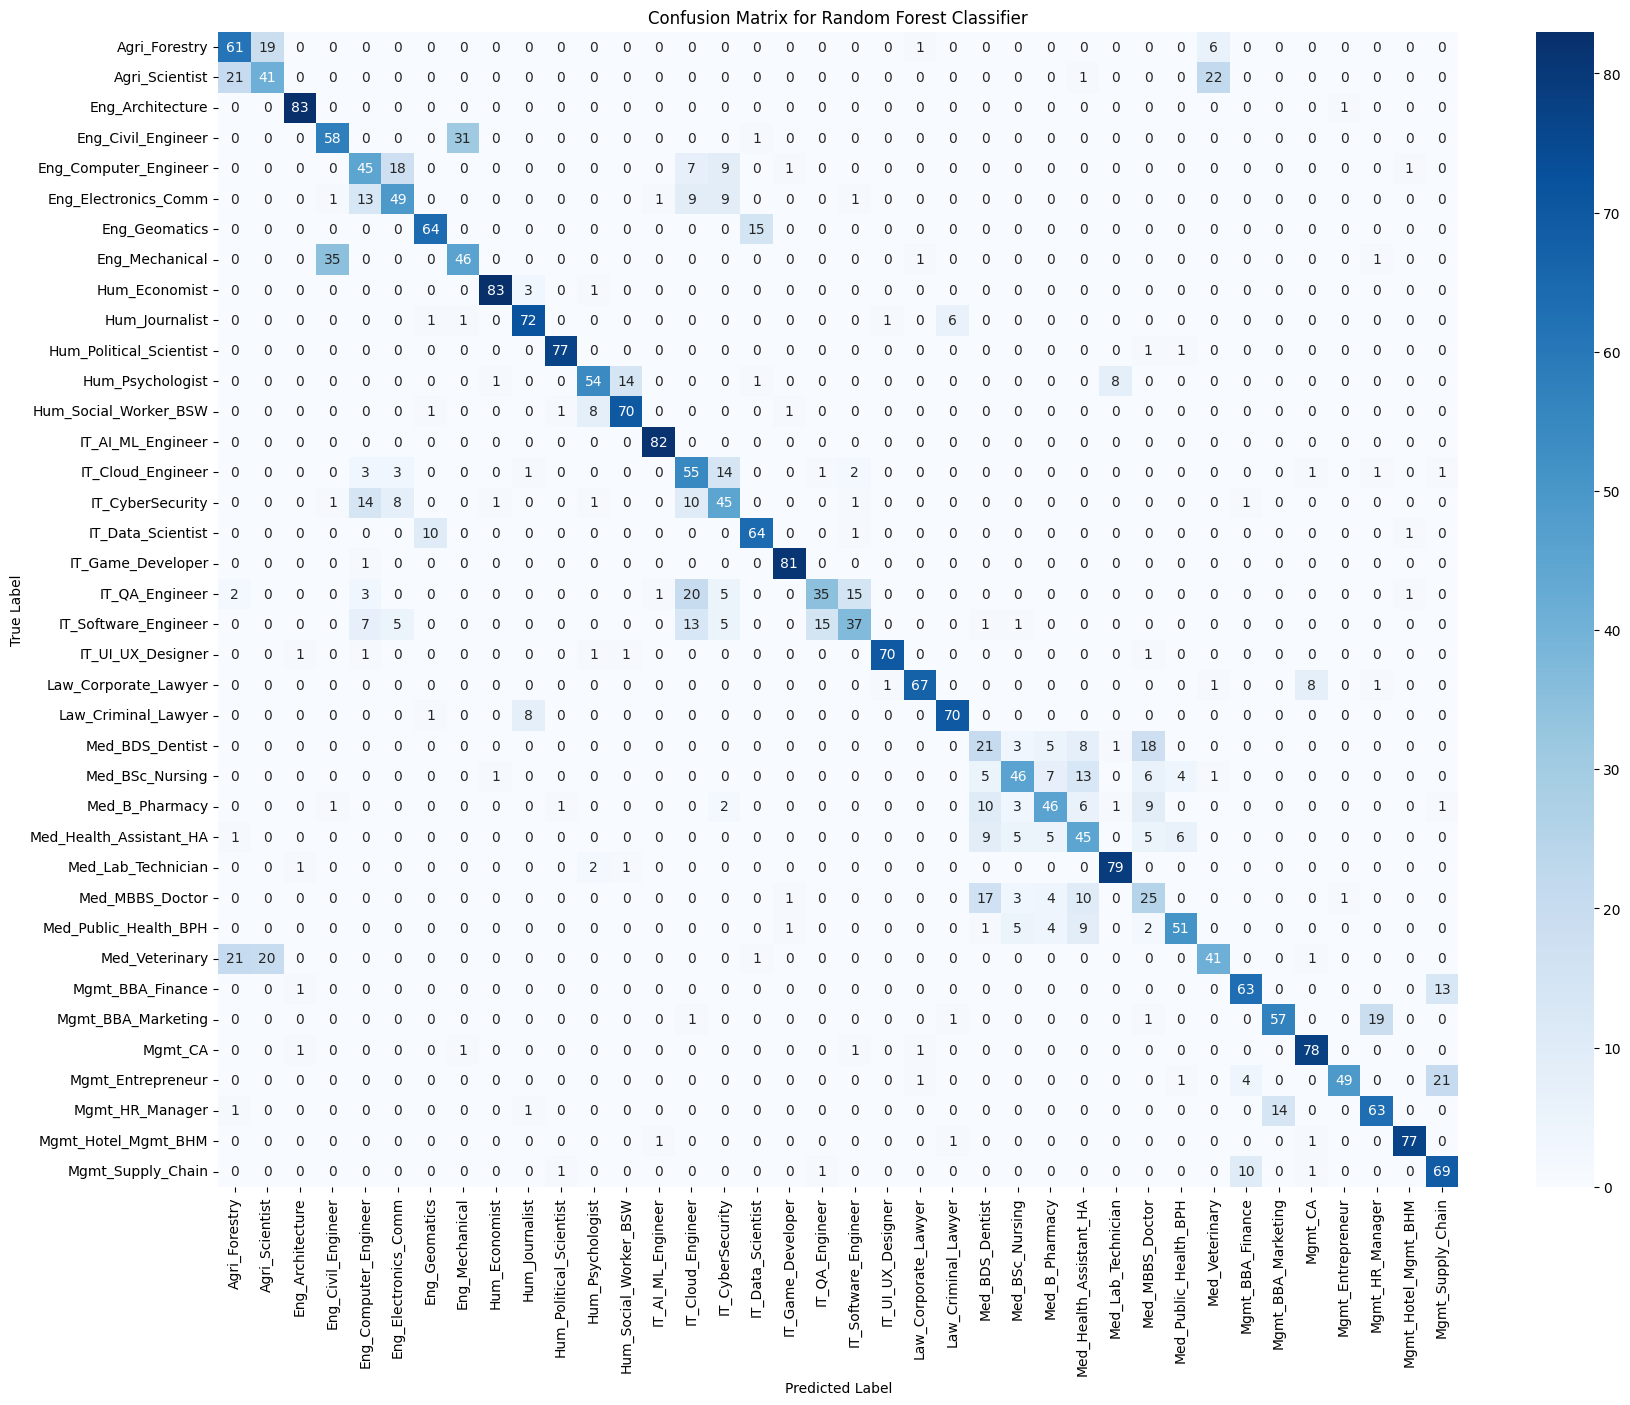

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
rf_cm = confusion_matrix(Y_test_encoded, rf_preds)

# Get the class names from the encoder used for Y
labels = target_encoder.classes_

# Plotting the confusion matrix
plt.figure(figsize=(20, 15))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

In [25]:
import joblib

joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(city_encoder, 'city_encoder.pkl')
joblib.dump(stream_encoder, 'stream_encoder.pkl')
joblib.dump(target_encoder, 'target_encoder.pkl')
print("Models and preprocessors successfully saved!")

Models and preprocessors successfully saved!


In [26]:
import numpy as np

# 1. Get the probabilities for all jobs
probabilities = rf.predict_proba(X_test)

# 2. Sort to find the top 3 highest scores
top3_indices = np.argsort(probabilities, axis=1)[:, ::-1][:, :3]

# 3. Get the actual names of the jobs
job_names = target_encoder.classes_

print("TOP 3 CAREER PREDICTIONS FOR 5 STUDENTS\n" + "="*40)

for i in range(5):
    print(f"Student {i+1} Career Matches:")

    for rank in range(3):
        # Find the job name based on the ranked index
        job_idx = top3_indices[i, rank]
        job = job_names[job_idx]

        # Print ONLY the rank and the job (No confidence score!)
        print(f"  {rank+1}. {job}")
    print("-" * 40)

TOP 3 CAREER PREDICTIONS FOR 5 STUDENTS
Student 1 Career Matches:
  1. Mgmt_BBA_Finance
  2. Mgmt_Supply_Chain
  3. Mgmt_Entrepreneur
----------------------------------------
Student 2 Career Matches:
  1. Med_BDS_Dentist
  2. Med_B_Pharmacy
  3. Med_MBBS_Doctor
----------------------------------------
Student 3 Career Matches:
  1. IT_Cloud_Engineer
  2. Eng_Computer_Engineer
  3. IT_CyberSecurity
----------------------------------------
Student 4 Career Matches:
  1. Med_Health_Assistant_HA
  2. Med_BSc_Nursing
  3. Med_MBBS_Doctor
----------------------------------------
Student 5 Career Matches:
  1. Eng_Mechanical
  2. Eng_Civil_Engineer
  3. IT_QA_Engineer
----------------------------------------
